In [3]:
import pandas as pd

orders = pd.read_csv("Desktop/phython/olist_orders_dataset.csv")

# Delivery rate
delivery_rate = (orders['order_status']=='delivered').mean()
print(delivery_rate)


0.9702034372140264


In [5]:
orders['purchase_hour'] = pd.to_datetime(orders['order_purchase_timestamp']).dt.hour

orders.groupby('purchase_hour').size()


purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
dtype: int64

In [7]:
pip install pandas matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.


In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [11]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

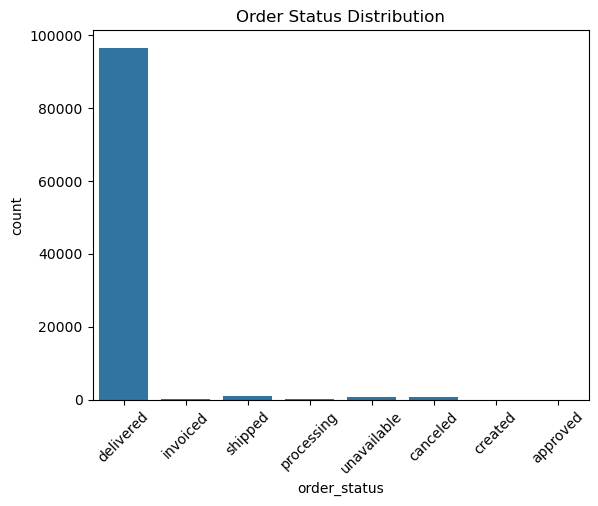

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=orders, x="order_status")
plt.xticks(rotation=45)
plt.title("Order Status Distribution")
plt.show()

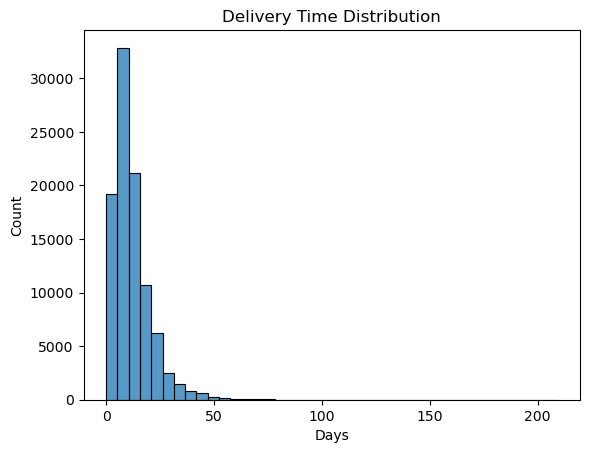

In [15]:
sns.histplot(orders['delivery_days'].dropna(), bins=40)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.show()

In [17]:
orders['delivered_flag'] = orders['order_status'].apply(
    lambda x: 1 if x == "delivered" else 0
)

In [19]:
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.weekday

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = orders[['purchase_month','purchase_day']]
y = orders['delivered_flag']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,predictions))

Accuracy: 0.9691286640856756


In [23]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [25]:
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.weekday
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour

orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

In [27]:
orders['delivered_flag'] = orders['order_status'].apply(
    lambda x: 1 if x == "delivered" else 0
)

In [29]:
features = ['purchase_month','purchase_day','purchase_hour']
X = orders[features]
y = orders['delivered_flag']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [35]:
predictions = model.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       597
           1       0.97      1.00      0.98     19292

    accuracy                           0.97     19889
   macro avg       0.48      0.50      0.49     19889
weighted avg       0.94      0.97      0.96     19889



In [39]:
importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

purchase_hour     0.538404
purchase_month    0.278358
purchase_day      0.183239
dtype: float64


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [43]:
probabilities = model.predict_proba(X_test)[:,1]

In [45]:
results = X_test.copy()
results["actual"] = y_test
results["predicted_probability"] = probabilities

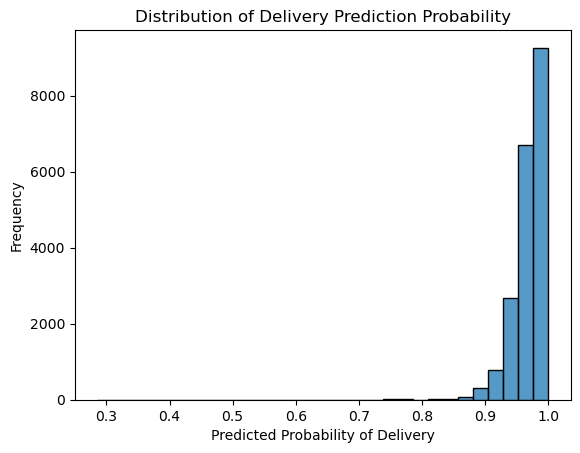

In [47]:
sns.histplot(results["predicted_probability"], bins=30)
plt.title("Distribution of Delivery Prediction Probability")
plt.xlabel("Predicted Probability of Delivery")
plt.ylabel("Frequency")
plt.show()

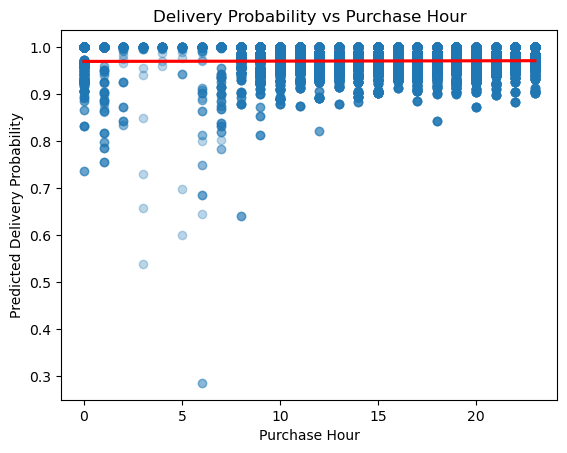

In [49]:
sns.regplot(
    x=results["purchase_hour"],
    y=results["predicted_probability"],
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Delivery Probability vs Purchase Hour")
plt.xlabel("Purchase Hour")
plt.ylabel("Predicted Delivery Probability")
plt.show()

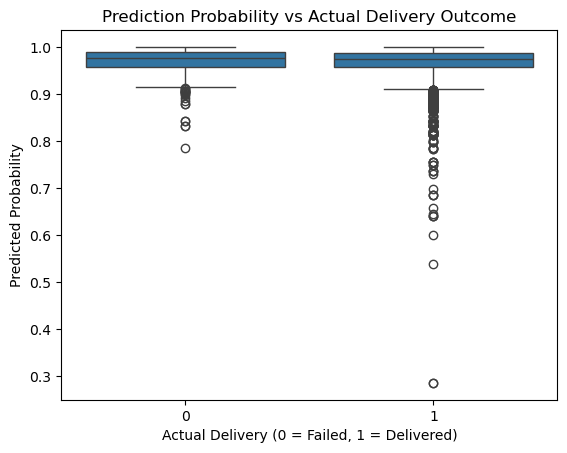

In [51]:
sns.boxplot(
    x=results["actual"],
    y=results["predicted_probability"]
)

plt.title("Prediction Probability vs Actual Delivery Outcome")
plt.xlabel("Actual Delivery (0 = Failed, 1 = Delivered)")
plt.ylabel("Predicted Probability")
plt.show()

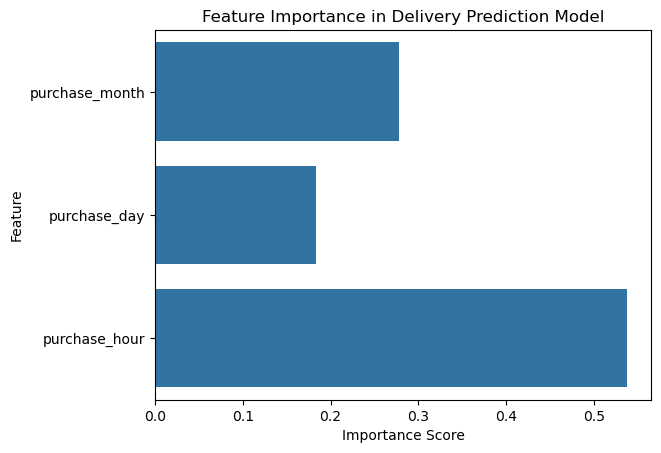

In [53]:
importance = pd.Series(model.feature_importances_, index=features)

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Feature Importance in Delivery Prediction Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

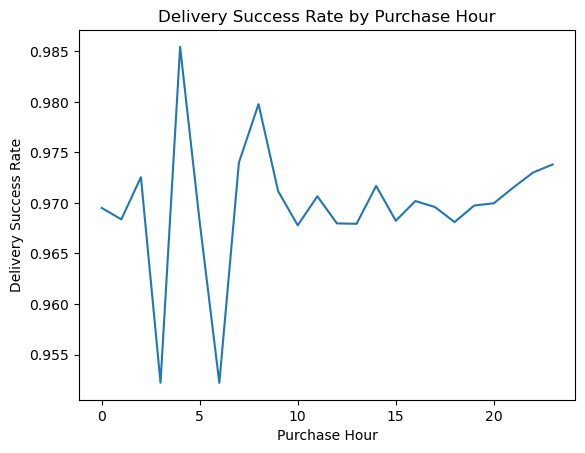

In [55]:
hourly_success = orders.groupby("purchase_hour")["delivered_flag"].mean()

plt.plot(hourly_success.index, hourly_success.values)
plt.title("Delivery Success Rate by Purchase Hour")
plt.xlabel("Purchase Hour")
plt.ylabel("Delivery Success Rate")
plt.show()

In [57]:
plt.savefig("delivery_probability_trend.png")

<Figure size 640x480 with 0 Axes>

In [59]:
orders.to_csv("orders_cleaned.csv", index=False)

In [61]:
results.to_csv("prediction_results.csv", index=False)

In [63]:
import os
os.getcwd()

'/Users/bonnythomas'

In [65]:
os.listdir()

['Untitled Folder',
 'delivery_probability_trend.png',
 'Untitled10.ipynb',
 'Untitled7.ipynb',
 '.config',
 'Music',
 '.condarc',
 'Untitled12.ipynb',
 '.mysqlsh-wb',
 'Untitled5.ipynb',
 'Ecommerce Analysis.ipynb',
 'Untitled1.ipynb',
 'Untitled16.ipynb',
 '.DS_Store',
 '.CFUserTextEncoding',
 '.xonshrc',
 'anaconda_projects',
 'Untitled3.ipynb',
 'Untitled14.ipynb',
 'Untitled.ipynb',
 '.zshrc',
 'Untitled4.ipynb',
 'Untitled13.ipynb',
 'Untitled6.ipynb',
 'Pictures',
 'Untitled11.ipynb',
 'Untitled15.ipynb',
 '.zsh_history',
 'Untitled2.ipynb',
 '.ipython',
 'predictive analysis.ipynb',
 'Desktop',
 'Library',
 '.matplotlib',
 'Untitled17.ipynb',
 'exam.ipynb',
 'Parallels',
 '.spyder-py3',
 'prediction_results.csv',
 'workbook 23 sept.ipynb',
 'orders_cleaned.csv',
 'Public',
 '.tcshrc',
 '.virtual_documents',
 '.anaconda',
 'Untitled8.ipynb',
 'Applications (Parallels)',
 'Movies',
 'Applications',
 '.Trash',
 '.ipynb_checkpoints',
 '.jupyter',
 'Documents',
 '.anydesk',
 'HCPana

In [69]:
orders.to_csv("/Users/bonnythomas/Downloads/orders_cleaned.csv", index=False)

In [71]:
results.to_csv("/Users/bonnythomas/Downloads/prediction_results.csv", index=False)